# Barridos de RPM — Datos Glitter PIV

Este notebook analiza cómo varían los parámetros cinemáticos del vórtice (perfil radial de velocidad tangencial, velocidad máxima y radio del núcleo) en función de la velocidad de giro del agitador magnético (**RPM**).

Basado en el análisis de `graficar_glitter.ipynb`, generaliza el procesamiento para una serie completa de mediciones:
1. **Detección automática** de series de barridos disponibles en `data glitter`.
2. **Selección interactiva** de la serie a analizar (por nombre o índice).
3. **Cálculo de los perfiles radiales** de velocidad tangencial $v_\theta(r)$ promediados por anillos concéntricos alrededor del centro del vórtice.
4. **Gráficos:**
   - **Las 5 curvas de velocidad tangencial superpuestas** (con bandas de desvío temporal $\pm \sigma$ y marcadores en los picos).
   - **Velocidad tangencial máxima ($v_{\theta,\text{máx}}$) en función del RPM** (con barras de error y ajuste lineal de escala).
   - **Radio de la velocidad tangencial máxima ($r(v_{\theta,\text{máx}})$) en función del RPM** (con línea de tendencia).
   - **Panel resumen integrado** con los 3 gráficos lado a lado.
   - **Comparativa global (opcional)** entre todas las series y fluidos.


In [17]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fontsize = 13
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)
AZUL, NARANJA, VERDE = "#2A6FB5", "#E08A2E", "#2CA02C"

DATA = Path("../data glitter")


## 1. Detección de Series Disponibles

Se buscan carpetas en `data glitter` que formen series numeradas de barridos de RPM.


In [18]:
carpetas_param = sorted(DATA.glob("*/*/parametros.json"))

series_disponibles = {}
for p in carpetas_param:
    folder_name = p.parent.parent.name
    # Extraer prefijo de fecha y hora: YYYY-MM-DD_HHMMSS_
    m = re.match(r"^\d{4}-\d{2}-\d{2}_\d{6}_(.+)$", folder_name)
    nombre_sin_fecha = m.group(1) if m else folder_name
    
    # Extraer el nombre base de la serie y el sufijo numérico (_1, _2, etc.)
    m_num = re.match(r"^(.*?)(?:_(\d+))?$", nombre_sin_fecha)
    serie_base = m_num.group(1)
    idx = m_num.group(2)
    
    if idx is not None:
        series_disponibles.setdefault(serie_base, []).append(p)

print(f"Se detectaron {len(series_disponibles)} series de barridos:\n")
filas_series = []
for i, (nombre_s, rutas) in enumerate(series_disponibles.items()):
    rpms = []
    for p in rutas:
        try:
            pj = json.loads(p.read_text(encoding="utf-8"))
            rpm = pj.get("grabacion_info", {}).get("velocidad_agitador_rpm")
            if rpm is not None:
                rpms.append(float(rpm))
        except Exception:
            pass
    rpms = sorted(rpms)
    filas_series.append({
        "Índice": i,
        "Serie": nombre_s,
        "Mediciones": len(rutas),
        "RPMs disponibles": ", ".join(f"{r:.0f}" for r in rpms) if rpms else "N/A",
    })

df_series = pd.DataFrame(filas_series).set_index("Índice")
display(df_series)


Se detectaron 5 series de barridos:



,Serie,Mediciones,RPMs disponibles
Índice,,,
0,barrido_velocidades_palangana,5,"800, 1000, 1200, 1400, 1600"
1,GLICERINA_barrido,5,"800, 1000, 1200, 1400, 1600"
2,TARRO_GRANDE_AGUA,5,"800, 1000, 1200, 1400, 1600"
3,TARRO_ALTO_AGUA,5,"800, 1000, 1200, 1400, 1600"
4,TARRO_CHICO_AGUA,5,"800, 1000, 1200, 1400, 1600"


## 2. Configurar y Cargar la Serie Elegida

- `SERIE`: nombre de la serie (o fragmento: `"palangana"`, `"glicerina"`, `"tarro_grande"`, `"tarro_alto"`, `"tarro_chico"`) o número de índice (`0`, `1`, `2`, ...).
- `SOLO_MEDIDOS`: `True` para excluir vectores descartados por validación PIV.
- `RESTAR_VELOCIDAD_DEL_CENTRO`: `True` para medir velocidades en el sistema propio del vórtice.


In [19]:
# ==============================================================================
# CONFIGURACIÓN: Elegir la serie y opciones
# ==============================================================================
SERIE = "tarro_chico"             # Nombre o índice de la serie
SOLO_MEDIDOS = True
RESTAR_VELOCIDAD_DEL_CENTRO = True


def resolver_serie(sel):
    nombres = list(series_disponibles.keys())
    if isinstance(sel, int):
        nombre = nombres[sel]
    else:
        candidatos = [n for n in nombres if sel.lower() in n.lower()]
        if not candidatos:
            raise ValueError(f"No se encontró ninguna serie que coincida con '{sel}'. Opciones disponibles: {nombres}")
        nombre = candidatos[0]
    return nombre, series_disponibles[nombre]


NOMBRE_SERIE, rutas_serie = resolver_serie(SERIE)
print(f"Serie seleccionada: '{NOMBRE_SERIE}' ({len(rutas_serie)} mediciones)\n")


def cargar_centro(cam, carpeta, k, cx_fijo, cy_fijo, frames):
    ruta = carpeta / cam["csv_centro"] if "csv_centro" in cam else None
    if ruta is None or not ruta.exists():
        return pd.DataFrame({"frame": frames, "xc": cx_fijo, "yc": cy_fijo, "seguido": 0,
                             "uc": 0.0, "vc": 0.0}).set_index("frame")
    c = pd.read_csv(ruta).set_index("frame")
    c["xc"], c["yc"] = c["xc_mm"] * k, c["yc_mm"] * k
    c["uc"] = np.gradient(c["xc"], c["t_s"])
    c["vc"] = np.gradient(c["yc"], c["t_s"])
    return c


def analizar_medicion(p_json):
    carpeta = p_json.parent
    P = json.loads(p_json.read_text(encoding="utf-8"))
    info = P.get("grabacion_info", {})
    rpm = float(info.get("velocidad_agitador_rpm", np.nan))
    
    # Seleccionar cámara superior
    cam_id = "A" if ("camaras" in P and "A" in P["camaras"]) else list(P["camaras"].keys())[0]
    cam = P["camaras"][cam_id]
        
    cal = cam["calibracion"]
    calibrada = cal.get("mm_por_px") is not None
    k = 0.1 if calibrada else 1.0                    # mm -> cm
    s = cal["mm_por_px"] * k if calibrada else 1.0   # cm/px o px/px

    todo = pd.read_csv(carpeta / cam["csv"])
    if "valido" not in todo:
        todo["valido"] = 1 - todo.get("interpolado", 0)
    todo["x"], todo["y"] = todo["x_mm"] * k, todo["y_mm"] * k
    todo["u"], todo["v"] = todo["u_mm_s"] * k, todo["v_mm_s"] * k

    cx_fijo, cy_fijo = np.array(cal["centro_vortice_px"]) * s
    centro = cargar_centro(cam, carpeta, k, cx_fijo, cy_fijo, np.unique(todo["frame"]))
    c = centro.loc[todo["frame"]]
    
    todo["dx"] = todo["x"].to_numpy() - c["xc"].to_numpy()
    todo["dy"] = todo["y"].to_numpy() - c["yc"].to_numpy()
    todo["r"] = np.hypot(todo["dx"], todo["dy"])
    ur, vr = todo["u"].to_numpy(), todo["v"].to_numpy()
    if RESTAR_VELOCIDAD_DEL_CENTRO:
        ur, vr = ur - c["uc"].to_numpy(), vr - c["vc"].to_numpy()
    
    r = todo["r"].where(todo["r"] > 0)
    todo["vt"] = (vr * todo["dx"] - ur * todo["dy"]) / r
    todo["vr"] = (ur * todo["dx"] + vr * todo["dy"]) / r

    df = todo[todo["valido"] == 1] if SOLO_MEDIDOS else todo
    df_vt = df.dropna(subset=["vt"])
    
    paso = np.diff(np.unique(todo["x"])).min()
    anillo = np.floor(df_vt["r"] / paso).astype(int)
    tabla = df_vt.groupby([anillo, df_vt["frame"]])[["vt", "vr", "t_s"]].mean()
    r_anillo = df_vt.groupby(anillo)["r"].mean()
    
    g = tabla.groupby(level=0)
    media, desvio = g.mean(), g.std()
    
    # Sentido predominante de rotación (vt > 0)
    sentido = np.sign(media["vt"].mean()) if media["vt"].mean() != 0 else 1.0
    vt_media = media["vt"] * sentido
    vt_desvio = desvio["vt"]
    
    # Máximo de velocidad tangencial y su radio correspondiente
    idx_max = vt_media.idxmax()
    r_max = r_anillo.loc[idx_max]
    v_max = vt_media.loc[idx_max]
    v_max_err = vt_desvio.loc[idx_max]

    descartados_pct = round(cam.get("descartados_pct", cam.get("interpolados_pct", 100 * (1 - todo["valido"].mean()))), 2)
    particula_pct = round(100 * centro["seguido"].mean(), 1) if "seguido" in centro else 0.0

    return {
        "grabacion": carpeta.parent.name,
        "p_json": p_json,
        "rpm": rpm,
        "r": r_anillo,
        "vt": vt_media,
        "vt_desvio": vt_desvio,
        "r_max": r_max,
        "v_max": v_max,
        "v_max_err": v_max_err,
        "paso": paso,
        "unidad": "cm" if calibrada else "px",
        "pares": todo["frame"].nunique(),
        "descartados_pct": descartados_pct,
        "particula_pct": particula_pct,
        "R_roi": cal["radio_roi_px"] * s,
    }


# Analizar todas las mediciones y ordenar por RPM creciente
datos_serie = [analizar_medicion(p) for p in rutas_serie]
datos_serie.sort(key=lambda d: d["rpm"])

u = datos_serie[0]["unidad"]
df_resumen = pd.DataFrame([
    {
        "Grabación": d["grabacion"],
        "RPM": d["rpm"],
        f"v_θ máx [{u}/s]": round(d["v_max"], 2),
        f"± σ [{u}/s]": round(d["v_max_err"], 2),
        f"r(v_máx) [{u}]": round(d["r_max"], 2),
        "Pares analizados": d["pares"],
        "Descartados [%]": d["descartados_pct"],
        "Partícula [%]": d["particula_pct"],
    }
    for d in datos_serie
])
display(df_resumen)


Serie seleccionada: 'TARRO_CHICO_AGUA' (5 mediciones)



,Grabación,RPM,v_θ máx [cm/s],± σ [cm/s],r(v_máx) [cm],Pares analizados,Descartados [%],Partícula [%]
0,2026-09-17_190809_TARRO_CHICO_AGUA_1,800.0,1.40,0.28,2.52,88,50.36,0.0
1,2026-09-17_192327_TARRO_CHICO_AGUA_2,1000.0,1.30,0.34,2.96,89,53.24,0.0
2,2026-09-17_192346_TARRO_CHICO_AGUA_3,1200.0,3.83,0.36,2.96,90,54.62,0.0
3,2026-09-17_192404_TARRO_CHICO_AGUA_4,1400.0,4.44,0.80,2.97,89,70.33,0.0
4,2026-09-17_192426_TARRO_CHICO_AGUA_5,1600.0,1.96,2.47,4.40,89,80.61,10.1


## 3. Curvas de Velocidad Tangencial Superpuestas

Se grafican las 5 curvas de velocidad tangencial $v_\theta(r)$ para los distintos RPMs en un mismo gráfico.
- Las curvas muestran cómo cambia el perfil radial con la velocidad del agitador.
- La zona sombreada indica la variabilidad temporal entre pares ($\pm \sigma$).
- La estrella sobre cada curva destaca el punto de velocidad máxima $(r(v_{\theta,\text{máx}}), v_{\theta,\text{máx}})$.


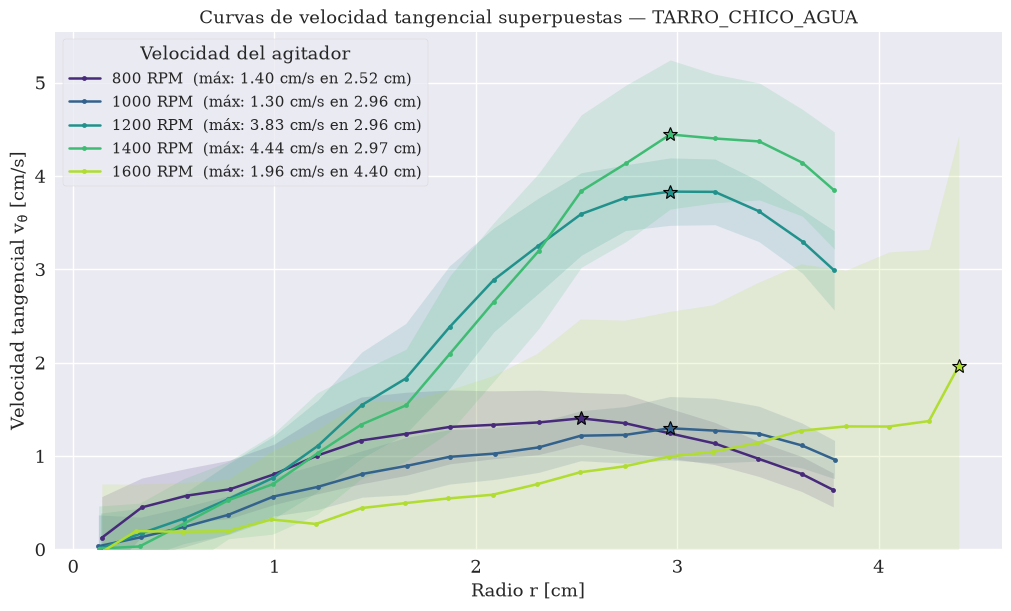

In [20]:
cmap = plt.cm.viridis
colores = [cmap(v) for v in np.linspace(0.12, 0.88, len(datos_serie))]

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for d, col in zip(datos_serie, colores):
    rpm = d["rpm"]
    r, vt, std = d["r"], d["vt"], d["vt_desvio"]
    lbl = f"{rpm:.0f} RPM  (máx: {d['v_max']:.2f} {u}/s en {d['r_max']:.2f} {u})"
    
    # Banda de desvío entre pares
    ax.fill_between(r, vt - std, vt + std, color=col, alpha=0.15, lw=0)
    # Perfil medio
    ax.plot(r, vt, "o-", ms=3.5, lw=1.8, color=col, label=lbl)
    # Pico destacado
    ax.plot(d["r_max"], d["v_max"], "*", ms=10, color=col, markeredgecolor="black", markeredgewidth=0.8, zorder=5)

ax.set_xlabel(f"Radio $r$ [{u}]")
ax.set_ylabel(rf"Velocidad tangencial $v_\theta$ [{u}/s]")
ax.set_title(f"Curvas de velocidad tangencial superpuestas — {NOMBRE_SERIE}")
ax.set_ylim(bottom=0)
ax.legend(title="Velocidad del agitador", fontsize=fontsize - 2, frameon=True)
plt.show()


## 4. Velocidad Tangencial Máxima en Función del RPM

Relación entre la velocidad tangencial máxima $v_{\theta,\text{máx}}$ y las revoluciones por minuto del agitador.
- Las barras de error representan la dispersión temporal $\pm \sigma$ en el anillo de máxima velocidad.
- Se incluye un ajuste lineal de referencia para contrastar si la velocidad máxima escala proporcionalmente a la velocidad del motor.


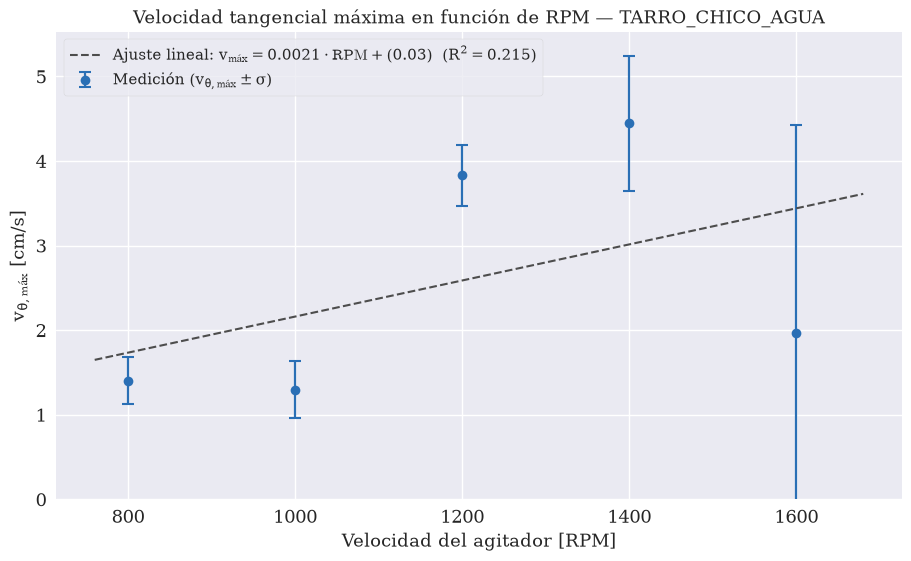

In [21]:
rpms = np.array([d["rpm"] for d in datos_serie])
v_maxs = np.array([d["v_max"] for d in datos_serie])
v_max_errs = np.array([d["v_max_err"] for d in datos_serie])

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

# Puntos medidos con error
ax.errorbar(rpms, v_maxs, yerr=v_max_errs, fmt="o", color=AZUL, ecolor=AZUL,
            elinewidth=1.6, capsize=4, capthick=1.5, ms=7, label=r"Medición ($v_{\theta,\mathrm{máx}} \pm \sigma$)")

# Ajuste lineal de tendencia
if len(rpms) >= 2:
    pol_v = np.polyfit(rpms, v_maxs, 1)
    rpm_fino = np.linspace(rpms.min() * 0.95, rpms.max() * 1.05, 100)
    residuos = v_maxs - np.polyval(pol_v, rpms)
    r2 = 1 - np.sum(residuos**2) / np.sum((v_maxs - np.mean(v_maxs))**2)
    ax.plot(rpm_fino, np.polyval(pol_v, rpm_fino), "--", color="0.3", lw=1.5,
            label=rf"Ajuste lineal: $v_\mathrm{{máx}} = {pol_v[0]:.4f} \cdot \mathrm{{RPM}} + ({pol_v[1]:.2f})$  ($R^2={r2:.3f}$)")

ax.set_xlabel("Velocidad del agitador [RPM]")
ax.set_ylabel(rf"$v_{{\theta,\mathrm{{máx}}}}$ [{u}/s]")
ax.set_title(f"Velocidad tangencial máxima en función de RPM — {NOMBRE_SERIE}")
ax.set_xticks(rpms)
ax.set_ylim(bottom=0)
ax.legend(fontsize=fontsize - 2, frameon=True)
plt.show()


## 5. Radio de la Velocidad Tangencial Máxima en Función del RPM

Relación entre la posición radial del pico $r(v_{\theta,\text{máx}})$ y la velocidad del agitador.
- En la teoría de vórtices viscosos (Rankine, Burgers, Lamb-Oseen), este radio define el límite del núcleo de rotación rígida y la transición al flujo irrotacional exterior.


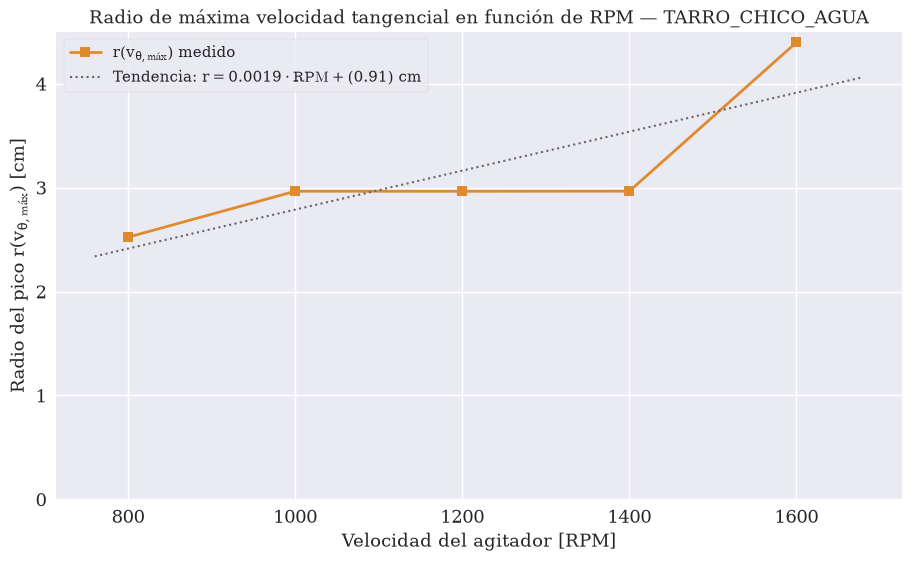

In [22]:
r_maxs = np.array([d["r_max"] for d in datos_serie])

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

ax.plot(rpms, r_maxs, "s-", color=NARANJA, lw=2, ms=7, label=r"$r(v_{\theta,\mathrm{máx}})$ medido")

# Ajuste lineal de tendencia
if len(rpms) >= 2:
    pol_r = np.polyfit(rpms, r_maxs, 1)
    rpm_fino = np.linspace(rpms.min() * 0.95, rpms.max() * 1.05, 100)
    ax.plot(rpm_fino, np.polyval(pol_r, rpm_fino), ":", color="0.4", lw=1.5,
            label=rf"Tendencia: $r = {pol_r[0]:.4f} \cdot \mathrm{{RPM}} + ({pol_r[1]:.2f})$ {u}")

ax.set_xlabel("Velocidad del agitador [RPM]")
ax.set_ylabel(rf"Radio del pico $r(v_{{\theta,\mathrm{{máx}}}})$ [{u}]")
ax.set_title(f"Radio de máxima velocidad tangencial en función de RPM — {NOMBRE_SERIE}")
ax.set_xticks(rpms)
ax.set_ylim(bottom=0)
ax.legend(fontsize=fontsize - 2, frameon=True)
plt.show()


## 6. Panel Resumen Integrado

Los tres gráficos reunidos en un único panel horizontal para una visualización completa.


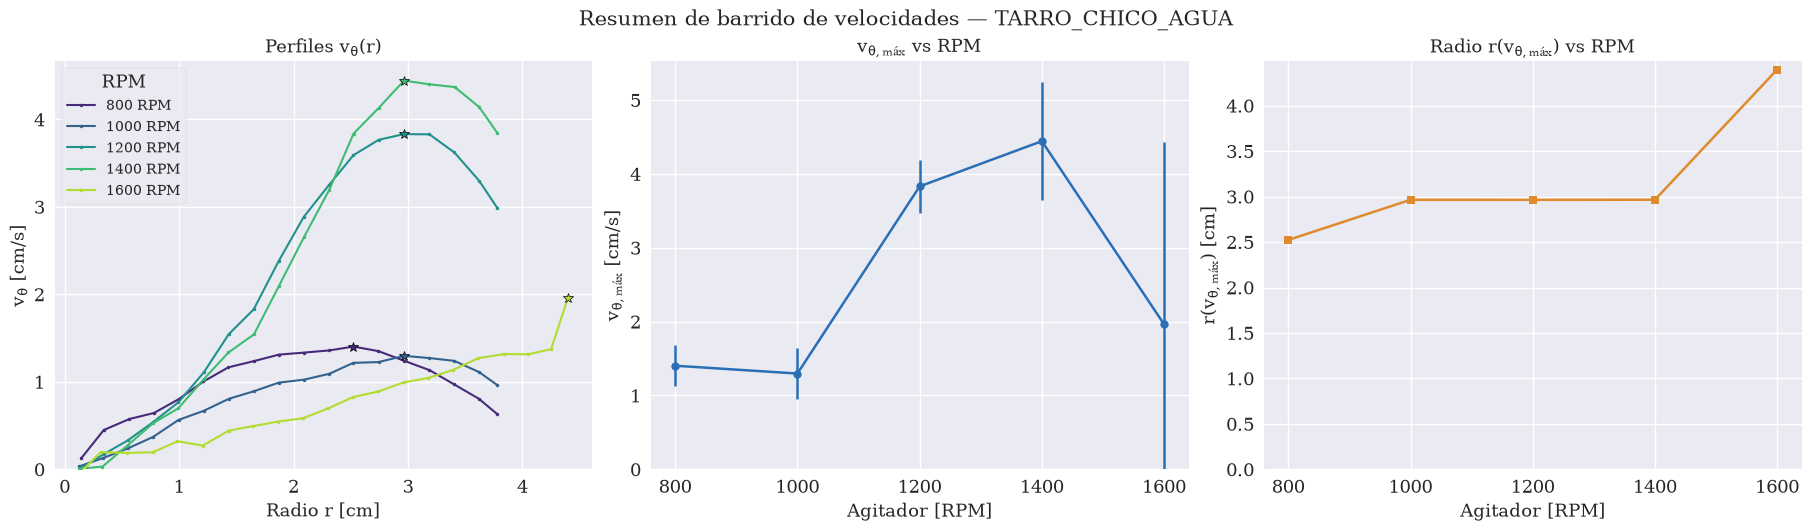

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)

# 1. Perfiles superpuestos
for d, col in zip(datos_serie, colores):
    ax1.plot(d["r"], d["vt"], "o-", ms=2.5, lw=1.5, color=col, label=f"{d['rpm']:.0f} RPM")
    ax1.plot(d["r_max"], d["v_max"], "*", ms=7, color=col, markeredgecolor="k", markeredgewidth=0.5)
ax1.set_xlabel(f"Radio $r$ [{u}]")
ax1.set_ylabel(rf"$v_\theta$ [{u}/s]")
ax1.set_title(r"Perfiles $v_\theta(r)$")
ax1.set_ylim(bottom=0)
ax1.legend(title="RPM", fontsize=fontsize - 3)

# 2. v_max vs RPM
ax2.errorbar(rpms, v_maxs, yerr=v_max_errs, fmt="o-", color=AZUL, ecolor=AZUL,
             capsize=3, lw=1.8, ms=6)
ax2.set_xlabel("Agitador [RPM]")
ax2.set_ylabel(rf"$v_{{\theta,\mathrm{{máx}}}}$ [{u}/s]")
ax2.set_title(r"$v_{\theta,\mathrm{máx}}$ vs RPM")
ax2.set_xticks(rpms)
ax2.set_ylim(bottom=0)

# 3. r_max vs RPM
ax3.plot(rpms, r_maxs, "s-", color=NARANJA, lw=1.8, ms=6)
ax3.set_xlabel("Agitador [RPM]")
ax3.set_ylabel(rf"$r(v_{{\theta,\mathrm{{máx}}}})$ [{u}]")
ax3.set_title(r"Radio $r(v_{\theta,\mathrm{máx}})$ vs RPM")
ax3.set_xticks(rpms)
ax3.set_ylim(bottom=0)

fig.suptitle(f"Resumen de barrido de velocidades — {NOMBRE_SERIE}", fontsize=fontsize + 2)
plt.show()


## 7. Comparativa Global entre Todas las Series (Opcional)

Compara la respuesta de todas las geometrías y fluidos medidos frente a la variación de RPM.


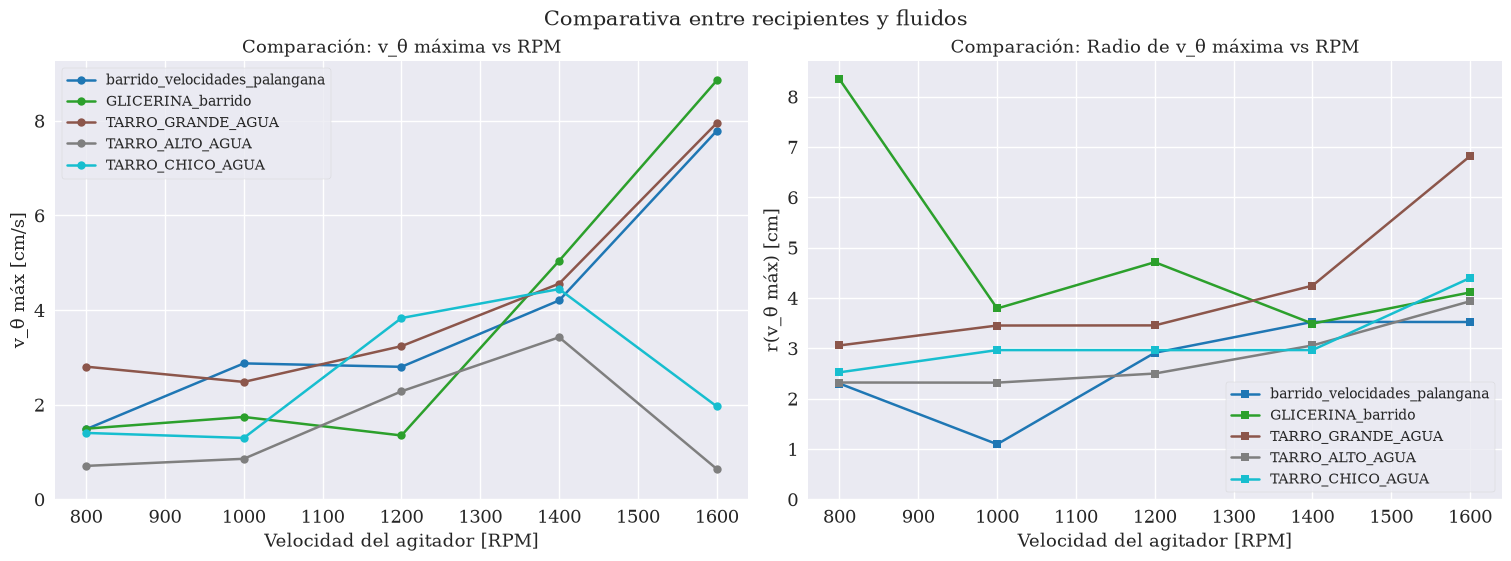

In [24]:
fig, (ax_v, ax_r) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

colores_series = plt.cm.tab10(np.linspace(0, 1, len(series_disponibles)))

for (nombre_s, rutas_s), col in zip(series_disponibles.items(), colores_series):
    try:
        serie_res = [analizar_medicion(p) for p in rutas_s]
        serie_res.sort(key=lambda d: d["rpm"])
        r_arr = [d["rpm"] for d in serie_res]
        vm_arr = [d["v_max"] for d in serie_res]
        rm_arr = [d["r_max"] for d in serie_res]
        
        ax_v.plot(r_arr, vm_arr, "o-", lw=1.8, ms=6, color=col, label=nombre_s)
        ax_r.plot(r_arr, rm_arr, "s-", lw=1.8, ms=6, color=col, label=nombre_s)
    except Exception as e:
        print(f"Error procesando serie {nombre_s}: {e}")

ax_v.set_xlabel("Velocidad del agitador [RPM]")
ax_v.set_ylabel(f"v_θ máx [{u}/s]")
ax_v.set_title("Comparación: v_θ máxima vs RPM")
ax_v.set_ylim(bottom=0)
ax_v.legend(fontsize=fontsize - 3)

ax_r.set_xlabel("Velocidad del agitador [RPM]")
ax_r.set_ylabel(f"r(v_θ máx) [{u}]")
ax_r.set_title("Comparación: Radio de v_θ máxima vs RPM")
ax_r.set_ylim(bottom=0)
ax_r.legend(fontsize=fontsize - 3)

fig.suptitle("Comparativa entre recipientes y fluidos", fontsize=fontsize + 2)
plt.show()
